In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
import networkx as nx
from PIL import Image
import io

def get_bond_indices(mol, atom_path):
    """Converts a sequence of atom indices into a list of bond indices."""
    bond_indices = []
    for i in range(len(atom_path) - 1):
        bond = mol.GetBondBetweenAtoms(atom_path[i], atom_path[i+1])
        if bond:
            bond_indices.append(bond.GetIdx())
    return bond_indices

def visualize_molecular_paths(smiles, atom_idx_1, atom_idx_2, img_name="paths.png"):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return
    
    # 1. Graph Logic (as before)
    G = nx.Graph()
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())
    
    all_paths = list(nx.all_simple_paths(G, source=atom_idx_1, target=atom_idx_2))
    all_paths.sort(key=len)
    
    shortest_atoms = all_paths[0]
    longest_atoms = all_paths[-1]
    
    shortest_bonds = get_bond_indices(mol, shortest_atoms)
    longest_bonds = get_bond_indices(mol, longest_atoms)

    # 2. Define Colors (RGB)
    # Shortest: Green (0, 0.8, 0.2) | Longest: Red/Orange (1, 0.4, 0.1)
    color_s = (0.0, 0.8, 0.2)
    color_l = (1.0, 0.4, 0.1)

    # 3. Create Highlight Maps
    atom_cols = {}
    bond_cols = {}

    # Map colors (Longest path is applied first, Shortest second so it "wins" on shared bonds)
    for idx in longest_atoms: atom_cols[idx] = color_l
    for idx in longest_bonds: bond_cols[idx] = color_l
    for idx in shortest_atoms: atom_cols[idx] = color_s
    for idx in shortest_bonds: bond_cols[idx] = color_s

    # 4. Draw Molecule
    # Ensure 2D coordinates exist
    Chem.rdDepictor.Compute2DCoords(mol)
    
    drawer = rdMolDraw2D.MolDraw2DCairo(600, 450) # Use Cairo for PNG
    opts = drawer.drawOptions()
    opts.useBWAtomPalette() # Clearer visualization for highlights
    opts.addAtomIndices = True # Useful for debugging

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol, 
        highlightAtoms=list(atom_cols.keys()),
        highlightAtomColors=atom_cols,
        highlightBonds=list(bond_cols.keys()),
        highlightBondColors=bond_cols
    )
    
    drawer.FinishDrawing()
    
    # Save/Show
    with open(img_name, "wb") as f:
        f.write(drawer.GetDrawingText())
    print(f"Visualization saved to {img_name}")

# Run the example
visualize_molecular_paths("CCC1=CC=C(C)C=C1", 0, 7)

Visualization saved to paths.png


In [2]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

def find_all_paths_rdkit(mol, start_idx, end_idx, path=None, all_paths=None):
    """
    Exhaustively find all simple paths between two atoms using RDKit atom neighbors.
    """
    if path is None:
        path = [start_idx]
    if all_paths is None:
        all_paths = []
        
    if start_idx == end_idx:
        all_paths.append(list(path))
        return all_paths

    atom = mol.GetAtomWithIdx(start_idx)
    for neighbor in atom.GetNeighbors():
        n_idx = neighbor.GetIdx()
        if n_idx not in path: # Ensure no atom (and thus no bond) is repeated
            path.append(n_idx)
            find_all_paths_rdkit(mol, n_idx, end_idx, path, all_paths)
            path.pop() # Backtrack
            
    return all_paths

def get_bond_indices(mol, atom_path):
    """Helper to convert atom sequence to RDKit bond indices."""
    return [mol.GetBondBetweenAtoms(atom_path[i], atom_path[i+1]).GetIdx() 
            for i in range(len(atom_path)-1)]

def run_analysis(smiles, idx1, idx2):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return
    
    # 1. Use RDKit's native shortest path (Dijkstra/BFS)
    shortest_path_atoms = list(Chem.rdmolops.GetShortestPath(mol, idx1, idx2))
    
    # 2. Find all paths to identify the longest one
    all_paths = find_all_paths_rdkit(mol, idx1, idx2)
    all_paths.sort(key=len)
    
    longest_path_atoms = all_paths[-1]
    
    # 3. Preparation for Visualization
    shortest_bonds = get_bond_indices(mol, shortest_path_atoms)
    longest_bonds = get_bond_indices(mol, longest_path_atoms)
    
    # Setup highlighting: Shortest (Green), Longest (Red)
    atom_highlights = {}
    bond_highlights = {}
    
    for a in longest_path_atoms: atom_highlights[a] = (1, 0.4, 0.4)
    for b in longest_bonds: bond_highlights[b] = (1, 0.4, 0.4)
    for a in shortest_path_atoms: atom_highlights[a] = (0.2, 0.8, 0.2)
    for b in shortest_bonds: bond_highlights[b] = (0.2, 0.8, 0.2)

    # 4. Generate SVG/PNG Visualization
    rdDepictor.Compute2DCoords(mol)
    drawer = rdMolDraw2D.MolDraw2DCairo(600, 450)
    
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=list(atom_highlights.keys()),
        highlightAtomColors=atom_highlights,
        highlightBonds=list(bond_highlights.keys()),
        highlightBondColors=bond_highlights
    )
    drawer.FinishDrawing()
    
    with open("path_analysis.png", "wb") as f:
        f.write(drawer.GetDrawingText())

    print(f"Total paths found: {len(all_paths)}")
    print(f"Shortest path: {len(shortest_path_atoms)-1} bonds")
    print(f"Longest path: {len(longest_path_atoms)-1} bonds")

# Example: Napthalene derivative
run_analysis("CC1=CC2=CC=CC=C2C=C1", 0, 5)

Total paths found: 4
Shortest path: 5 bonds
Longest path: 7 bonds


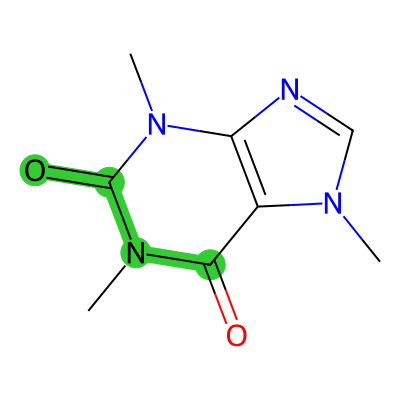

Shortest path length: 3 bonds


In [3]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

def visualize_shortest_path(smiles, idx1, idx2):
    # 1. Create Molecule and compute 2D coordinates
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        print("Invalid SMILES")
        return
    rdDepictor.Compute2DCoords(mol)

    # 2. Get Shortest Path using RDKit's built-in C++ implementation
    # Returns a tuple of atom indices (e.g., (0, 1, 2, 3))
    path_atoms = Chem.rdmolops.GetShortestPath(mol, idx1, idx2)
    
    if not path_atoms:
        print(f"No path found between atom {idx1} and {idx2}")
        return

    # 3. Identify the bonds connecting those atoms
    path_bonds = []
    for i in range(len(path_atoms) - 1):
        bond = mol.GetBondBetweenAtoms(path_atoms[i], path_atoms[i+1])
        path_bonds.append(bond.GetIdx())

    # 4. Setup the Drawer (SVG is best for Jupyter)
    drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)
    
    # Optional: Customize highlighting color (Green: 0.2, 0.8, 0.2)
    highlight_color = (0.2, 0.8, 0.2)
    atom_colors = {idx: highlight_color for idx in path_atoms}
    bond_colors = {idx: highlight_color for idx in path_bonds}

    # 5. Draw
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, 
        mol, 
        highlightAtoms=list(path_atoms),
        highlightAtomColors=atom_colors,
        highlightBonds=path_bonds,
        highlightBondColors=bond_colors
    )
    drawer.FinishDrawing()

    # 6. Display in Jupyter
    display(SVG(drawer.GetDrawingText()))
    print(f"Shortest path length: {len(path_bonds)} bonds")

# --- Example Usage ---
# Using Caffeine as an example
# Visualizing path between the two carbonyl oxygens
visualize_shortest_path("CN1C=NC2=C1C(=O)N(C(=O)N2C)C", 6, 10)

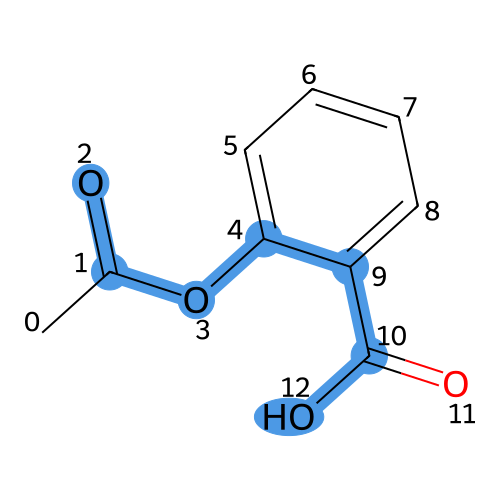

Shortest path from 2 to 12 involves 6 bonds.
Atom sequence: [2, 1, 3, 4, 9, 10, 12]


In [5]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

def visualize_shortest_path_with_indices(smiles, idx1, idx2):
    # 1. Initialize Molecule
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        print("Invalid SMILES string.")
        return
    
    # 2. Compute 2D coordinates for clear drawing
    rdDepictor.Compute2DCoords(mol)

    # 3. Calculate shortest path (Atom Indices)
    # This uses RDKit's built-in Dijkstra-based algorithm
    path_atoms = Chem.rdmolops.GetShortestPath(mol, idx1, idx2)
    
    if not path_atoms:
        print(f"No path found between atom {idx1} and {idx2}")
        return

    # 4. Map atoms to bond indices for highlighting
    path_bonds = []
    for i in range(len(path_atoms) - 1):
        bond = mol.GetBondBetweenAtoms(path_atoms[i], path_atoms[i+1])
        path_bonds.append(bond.GetIdx())

    # 5. Configure the Drawer
    drawer = rdMolDraw2D.MolDraw2DSVG(500, 500)
    options = drawer.drawOptions()
    
    # --- Key Additions ---
    options.addAtomIndices = True  # Labels every atom with its index
    options.annotationFontScale = 0.75 # Adjust index size for readability
    
    # Set highlight color (Light Blue: 0.3, 0.6, 0.9)
    highlight_color = (0.3, 0.6, 0.9)
    atom_colors = {idx: highlight_color for idx in path_atoms}
    bond_colors = {idx: highlight_color for idx in path_bonds}

    # 6. Draw the molecule with highlights
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, 
        mol, 
        highlightAtoms=list(path_atoms),
        highlightAtomColors=atom_colors,
        highlightBonds=path_bonds,
        highlightBondColors=bond_colors
    )
    drawer.FinishDrawing()

    # 7. Output to Jupyter
    display(SVG(drawer.GetDrawingText()))
    print(f"Shortest path from {idx1} to {idx2} involves {len(path_bonds)} bonds.")
    print(f"Atom sequence: {list(path_atoms)}")

# --- Example: Aspirin ---
# Visualizing path between the acetyl oxygen and the carboxyl oxygen
visualize_shortest_path_with_indices("CC(=O)OC1=CC=CC=C1C(=O)O", 2, 12)

Path Length: 6 bonds.
Source (Green): Atom 9 | Sink (Red): Atom 0


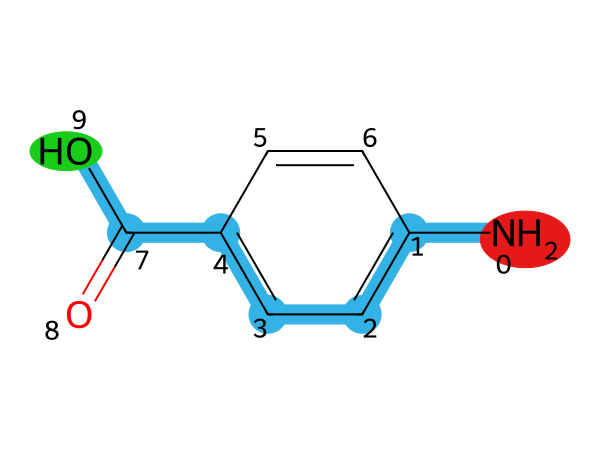

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

def visualize_path_between_smarts(smiles, smarts_source, source_atom_idx, smarts_sink, sink_atom_idx, img_size=(600, 450)):
    # 1. Load Molecule and SMARTS
    mol = Chem.MolFromSmiles(smiles)
    q_source = Chem.MolFromSmarts(smarts_source)
    q_sink = Chem.MolFromSmarts(smarts_sink)
    
    if not all([mol, q_source, q_sink]):
        print("Error: Check your SMILES or SMARTS syntax.")
        return

    # 2. Identify start and end indices
    match_source = mol.GetSubstructMatch(q_source)
    match_sink = mol.GetSubstructMatch(q_sink)
    
    if not match_source or not match_sink:
        print(f"Match failed. Source: {bool(match_source)}, Sink: {bool(match_sink)}")
        return
    
    # We use the specified atom index of each match
    idx1, idx2 = match_source[source_atom_idx], match_sink[sink_atom_idx]

    # 3. Compute Shortest Path
    path_atoms = list(Chem.rdmolops.GetShortestPath(mol, idx1, idx2))
    if not path_atoms:
        print(f"No path exists between atom {idx1} and {idx2}.")
        return
        
    path_bonds = [mol.GetBondBetweenAtoms(path_atoms[i], path_atoms[i+1]).GetIdx() 
                  for i in range(len(path_atoms) - 1)]

    # 4. Configure Visualization
    rdDepictor.Compute2DCoords(mol)
    drawer = rdMolDraw2D.MolDraw2DSVG(img_size[0], img_size[1])
    opts = drawer.drawOptions()
    opts.addAtomIndices = True
    opts.annotationFontScale = 0.7
    
    # Define color scheme (RGB)
    color_path = (0.2, 0.7, 0.9)   # Light Blue
    color_start = (0.1, 0.8, 0.1)  # Green
    color_end = (0.9, 0.1, 0.1)    # Red

    # Map colors to indices
    atom_colors = {idx: color_path for idx in path_atoms}
    atom_colors[idx1] = color_start
    atom_colors[idx2] = color_end
    bond_colors = {idx: color_path for idx in path_bonds}

    # 5. Render
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=list(atom_colors.keys()),
        highlightAtomColors=atom_colors,
        highlightBonds=path_bonds,
        highlightBondColors=bond_colors
    )
    drawer.FinishDrawing()

    print(f"Path Length: {len(path_bonds)} bonds.")
    print(f"Source (Green): Atom {idx1} | Sink (Red): Atom {idx2}")
    display(SVG(drawer.GetDrawingText()))

# --- Example Usage ---
# SMILES: A typical drug-like scaffold
# SMARTS 1: Carboxylic Acid oxygen
# SMARTS 2: Amine Nitrogen
smi = "NC1=CC=C(C=C1)C(=O)O"
visualize_path_between_smarts(smi, "[O;H1]", 0, "[NH2]", 0)

Path Length: 8 bonds.
Source (Green): Atom 34 | Sink (Red): Atom 29


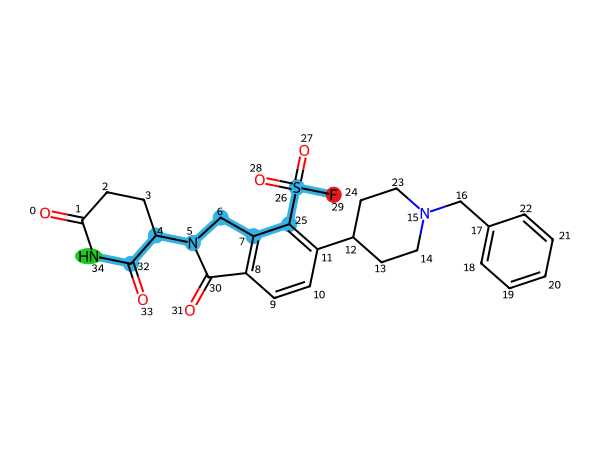

Path Length: 9 bonds.
Source (Green): Atom 34 | Sink (Red): Atom 27


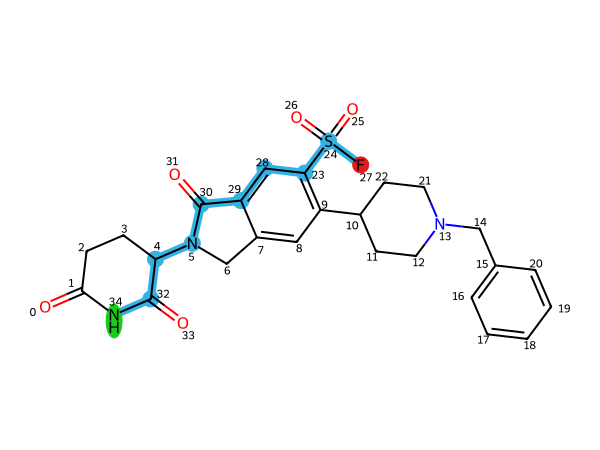

Path Length: 16 bonds.
Source (Green): Atom 34 | Sink (Red): Atom 24


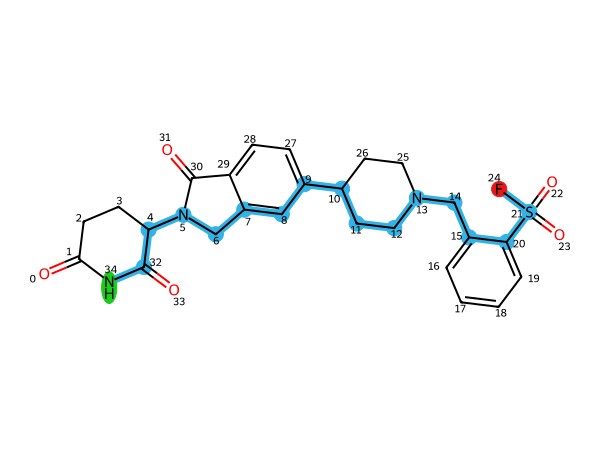

Path Length: 17 bonds.
Source (Green): Atom 34 | Sink (Red): Atom 23


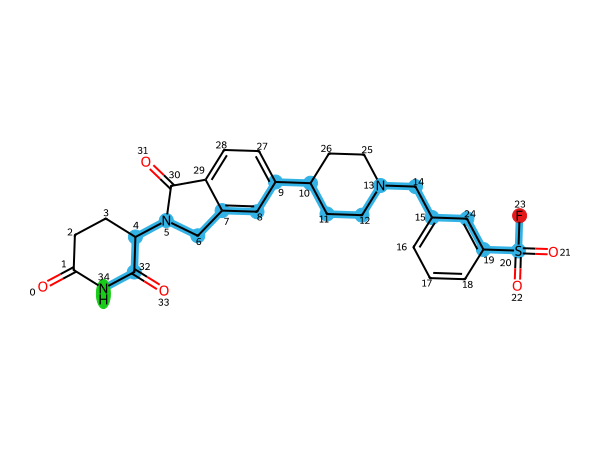

Path Length: 18 bonds.
Source (Green): Atom 34 | Sink (Red): Atom 22


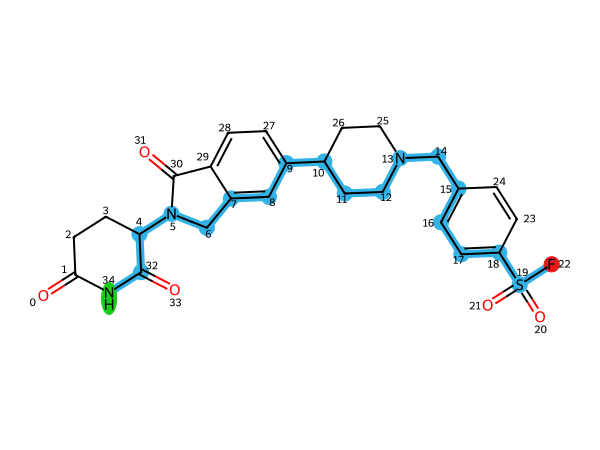

Path Length: 8 bonds.
Source (Green): Atom 34 | Sink (Red): Atom 28


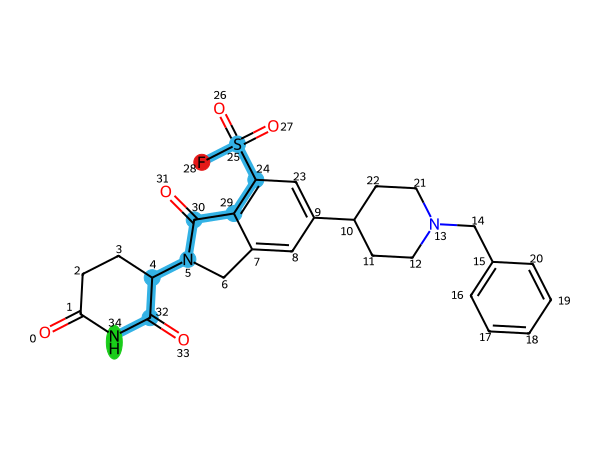

In [13]:
supplier = Chem.SDMolSupplier('covalent_docking_VS/IKZF2/covalent_cereblon_binders_final_clean_inc_sulf.sdf')
# Convert to list to enable slicing (filtering out None values for safety)
mol_list = [m for m in supplier if m is not None][-6:]

for i in mol_list:
    smi = Chem.MolToSmiles(i)
    visualize_path_between_smarts(smi, "[!#1]1([!#1][!#1]-[#6](-[#7]-[#6]-1=[#8])=[#8])", 4, "[!#1]-[#16](=[#8])(=[#8])-[#9]", 4)